In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from cv_tuning import prepare_train_test_data, CV_FOLDS
from kernels import KERNEL_REGISTRY
from optimizers import (
    robbins_monro_svm, adagrad_svm, adam_svm,
    predict_rm, print_rm_eval_report,
    tune_optimizer_joint_cv, fit_best, run_svm_experiments, repeated_eval_comparison,
    RM_PARAM_GRID, ADAGRAD_PARAM_GRID, ADAM_PARAM_GRID,
    best_per_kernel,
)

data = prepare_train_test_data(filepath='../data/ridings.csv')
X_train     = data['X_train_proc']
X_test      = data['X_test_proc']
y_train     = data['y_train'].values
y_test      = data['y_test'].values
y_train_svm = data['y_train_svm']
y_test_svm  = data['y_test_svm']

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'Class balance    : {y_train.mean():.2%} Liberal (train)')

Training samples : 273
Test samples     : 69
Features         : 20
Class balance    : 49.82% Liberal (train)


# Robbins-Monro SVM — Optimization
### Soft-margin SVM using stochastic subgradient descent (Robbins-Monro)
### in the dual/representer form with kernels..

**loss minimised:**

$$
L(\boldsymbol{\alpha}, b) = \frac{1}{n}\sum_{j=1}^{n} \max\!\big\{0,\; 1 - y_j\,\big(\mathbf{K}_j^\top \boldsymbol{\alpha} - b\big)\big\} + \lambda \|\mathbf{w}\|^2
$$

where $\mathbf{w} = \sum_i \alpha_i \,\varphi(\mathbf{x}_i)$ and $\mathbf{K}$ is the Gram matrix for the chosen kernel.

## 1. Hyperparameter Search

Joint grid search over **kernel hyperparameters** (from `KERNEL_REGISTRY`) and **RM optimizer settings** ($\lambda$, $\eta_0$, decay, epochs).

In [2]:
print(f'RM grid size     : {len(RM_PARAM_GRID)} combos per kernel setting')
total = sum(len(KERNEL_REGISTRY[k]["param_grid"]) for k in KERNEL_REGISTRY)
print(f'Kernel settings  : {total} total across all kernels')
print(f'Total configs    : {total * len(RM_PARAM_GRID)} × 10 folds\n')

joint = tune_optimizer_joint_cv(
    robbins_monro_svm, X_train, y_train,
    param_grid=RM_PARAM_GRID,
    verbose=True,
)

RM grid size     : 36 combos per kernel setting
Kernel settings  : 42 total across all kernels
Total configs    : 1512 × 10 folds

  linear    combos tested:   36  best_cv so far: 0.7913  [21s]
  rbf       combos tested:  216  best_cv so far: 0.8243  [127s]
  poly      combos tested: 1188  best_cv so far: 0.8351  [707s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8351  [918s]


In [3]:
df = joint['results_df'].copy()

idx_best = df.groupby('kernel')['mean_cv'].idxmax()
per_kernel_best_df = df.loc[idx_best].sort_values('mean_cv', ascending=False).reset_index(drop=True)

display_df = per_kernel_best_df[['kernel', 'kernel_params', 'lambda_reg', 'eta0', 'decay', 'n_epochs', 'mean_cv', 'std_cv']].copy()
display_df.columns = ['Kernel', 'Kernel Params', 'λ', 'η₀', 'Decay', 'Epochs', 'Mean CV Acc', 'Std CV']
display_df['Mean CV Acc'] = display_df['Mean CV Acc'].map('{:.4f}'.format)
display_df['Std CV']      = display_df['Std CV'].map('±{:.4f}'.format)
display_df.index = display_df.index + 1
display_df.index.name = '#'
display_df.style.set_caption('Best RM configuration per kernel (10-fold CV)')

,Kernel,Kernel Params,λ,η₀,Decay,Epochs,Mean CV Acc,Std CV
#,,,,,,,,
1,poly,"{'degree': 4, 'gamma': 0.1, 'coef0': 1.0}",0.001000,0.010000,0.010000,50,0.8351,±0.0506
2,rbf,{'gamma': 0.1},0.001000,0.500000,0.100000,50,0.8243,±0.0481
3,linear,{},0.001000,0.100000,0.100000,100,0.7913,±0.0516
4,sigmoid,"{'gamma': 0.01, 'coef0': 0.0}",0.001000,0.100000,0.010000,50,0.7288,±0.0830


## 2. Refit & Evaluation

In [4]:
# ── Hardcoded best RM config
best_rm_config = joint['best_result'].copy()

# best_rm_config = {
#     "kernel": "poly",
#     "kernel_params": {"degree": ..., "gamma": ..., "coef0": ...},
#     "lambda_reg": ...,
#     "eta0": ...,
#     "decay": ...,
#     "n_epochs": ...,
#     "mean_cv": ...,
# }

print(f"kernel         : {best_rm_config['kernel']}")
print(f"kernel_params  : {best_rm_config['kernel_params']}")
print(f"lambda_reg     : {best_rm_config['lambda_reg']}")
print(f"eta0           : {best_rm_config['eta0']}")
print(f"decay          : {best_rm_config['decay']}")
print(f"n_epochs       : {best_rm_config['n_epochs']}")
print(f"mean_cv        : {best_rm_config['mean_cv']:.4f}")

kernel         : poly
kernel_params  : {'degree': 4, 'gamma': 0.1, 'coef0': 1.0}
lambda_reg     : 0.001
eta0           : 0.01
decay          : 0.01
n_epochs       : 50
mean_cv        : 0.8351


In [5]:
final = fit_best(
    robbins_monro_svm,
    X_train, y_train_svm, X_test, y_test_svm,
    best_rm_config, n_epochs_override=300,
)
y_pred_final = predict_rm(final, X_test)

print_rm_eval_report(y_test, y_pred_final,
                     model_name=f"RM SVM ({best_rm_config['kernel']}, tuned)")

=== RM SVM (poly, tuned) ===
Test Accuracy : 0.8696

  Std    : 0.3368
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.94      0.88        35
           1       0.93      0.79      0.86        34

    accuracy                           0.87        69
   macro avg       0.88      0.87      0.87        69
weighted avg       0.88      0.87      0.87        69

--- Confusion Matrix ---
[[33  2]
 [ 7 27]]



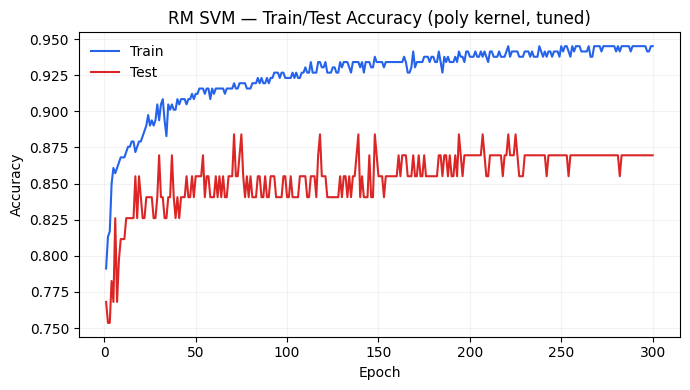

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
epochs = range(1, len(final['train_acc_history']) + 1)
ax.plot(epochs, final['train_acc_history'], label='Train', color='#2563eb', lw=1.5)
ax.plot(epochs, final['test_acc_history'],  label='Test',  color='#dc2626', lw=1.5)
ax.set(xlabel='Epoch', ylabel='Accuracy',
       title=f"RM SVM — Train/Test Accuracy ({best_rm_config['kernel']} kernel, tuned)")
ax.legend(frameon=False)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

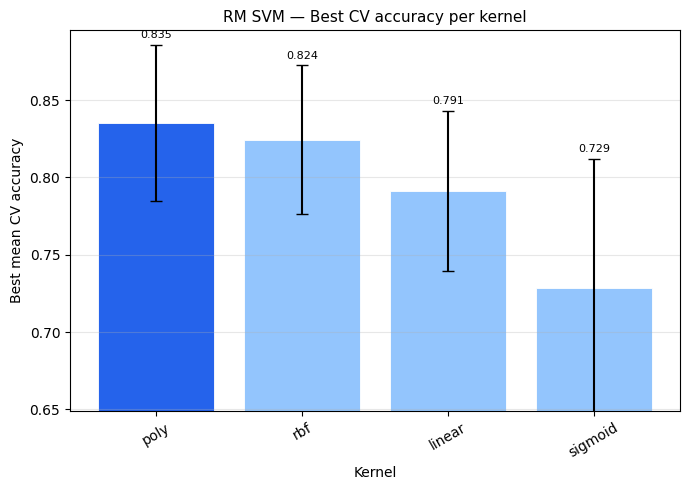

In [7]:
bpk = best_per_kernel(joint['results_df'])

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(bpk))]
bars = ax.bar(bpk['kernel'], bpk['mean_cv'],
              yerr=bpk['std_cv'], capsize=4,
              color=colors, edgecolor='white', linewidth=0.6)
ax.set_title('RM SVM — Best CV accuracy per kernel', fontsize=11)
ax.set_xlabel('Kernel')
ax.set_ylabel('Best mean CV accuracy')
ax.set_ylim(max(0, bpk['mean_cv'].min() - 0.08), min(1, bpk['mean_cv'].max() + 0.06))
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar, val, std in zip(bars, bpk['mean_cv'], bpk['std_cv']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# AdaGrad SVM — Optimization

Soft-margin SVM using AdaGrad

in the dual/representer form with kernels.

**loss minimised:**

$$
L(\alpha,b)=\frac{1}{n}\sum_{j=1}^{n}\max\{0,\,1-y_j(K_j^\top \alpha-b)\}+\lambda\|w\|^2
$$

where $w=\sum_i \alpha_i \varphi(x_i)$ and $K$ is the Gram matrix for the chosen kernel.

AdaGrad uses the same objective as the Robbins–Monro SVM above,

but replaces the global decaying step-size with coordinate-wise adaptive learning rates:

$$
G_t=\sum_{s\le t} g_s^2,\qquad
\theta_{t+1}=\theta_t-\frac{\eta_0}{\sqrt{G_t+\varepsilon}}\,g_t
$$

## 1 Baseline: AdaGrad with Joint Kernel Search

In [8]:
ada_out = run_svm_experiments(
    adagrad_svm, ADAGRAD_PARAM_GRID,
    filepath="../data/ridings.csv",
    n_epochs_override=150,
    verbose=True,
)

  linear    combos tested:   36  best_cv so far: 0.7951  [24s]
  rbf       combos tested:  216  best_cv so far: 0.8209  [167s]
  poly      combos tested: 1188  best_cv so far: 0.8385  [970s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8385  [1236s]


In [9]:
ada_best = ada_out["search"]["best_result"]

ada_df = pd.DataFrame([{
    "Kernel":        ada_best["kernel"],
    "Kernel Params": str(ada_best["kernel_params"]),
    "lambda_reg":    ada_best["lambda_reg"],
    "eta0":          ada_best["eta0"],
    "eps":           ada_best["eps"],
    "n_epochs":      ada_best["n_epochs"],
    "Mean CV":       round(ada_best["mean_cv"], 4),
    "Std CV":        round(ada_best["std_cv"], 4),
    "Test Acc":      round(ada_out["test_acc"], 4),
}])
ada_df.index = ada_df.index + 1
ada_df.index.name = "#"
ada_df.style.set_caption("Table — AdaGrad SVM best setting")

,Kernel,Kernel Params,lambda_reg,eta0,eps,n_epochs,Mean CV,Std CV,Test Acc
#,,,,,,,,,
1,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 10}",0.100000,0.010000,0.000000,100,0.838500,0.047800,0.855100


In [10]:
# ── Hardcoded best AdaGrad config
best_adagrad_config = ada_out['search']['best_result'].copy()


# best_adagrad_config = {
#     "kernel": "poly",
#     "kernel_params": {"degree": ..., "gamma": ..., "coef0": ...},
#     "lambda_reg": ...,
#     "eta0": ...,
#     "eps": ...,
#     "n_epochs": ...,
#     "mean_cv": ...,
# }

print(f"kernel         : {best_adagrad_config['kernel']}")
print(f"kernel_params  : {best_adagrad_config['kernel_params']}")
print(f"lambda_reg     : {best_adagrad_config['lambda_reg']}")
print(f"eta0           : {best_adagrad_config['eta0']}")
print(f"eps            : {best_adagrad_config['eps']}")
print(f"n_epochs       : {best_adagrad_config['n_epochs']}")
print(f"mean_cv        : {best_adagrad_config['mean_cv']:.4f}")

kernel         : poly
kernel_params  : {'degree': 2, 'gamma': 1.0, 'coef0': 10}
lambda_reg     : 0.1
eta0           : 0.01
eps            : 1e-08
n_epochs       : 100
mean_cv        : 0.8385


In [11]:
print_rm_eval_report(
    ada_out["data"]["y_test"],
    ada_out["y_pred"],
    model_name="AdaGrad SVM"
)

=== AdaGrad SVM ===
Test Accuracy : 0.8551

  Std    : 0.3520
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.94      0.87        35
           1       0.93      0.76      0.84        34

    accuracy                           0.86        69
   macro avg       0.87      0.85      0.85        69
weighted avg       0.87      0.86      0.85        69

--- Confusion Matrix ---
[[33  2]
 [ 8 26]]



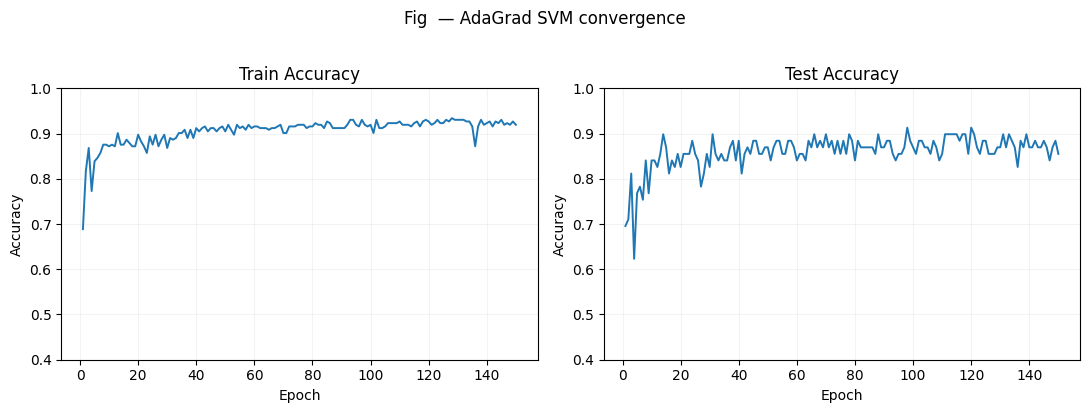

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs = range(1, len(ada_out["fit"]["train_acc_history"]) + 1)

axes[0].plot(epochs, ada_out["fit"]["train_acc_history"], lw=1.4)
axes[1].plot(epochs, ada_out["fit"]["test_acc_history"], lw=1.4)

for ax, title in zip(axes, ['Train Accuracy', 'Test Accuracy']):
    ax.set(xlabel='Epoch', ylabel='Accuracy', title=title)
    ax.grid(True, alpha=0.15)
    ax.set_ylim(0.4, 1.0)

fig.suptitle('Fig  — AdaGrad SVM convergence', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

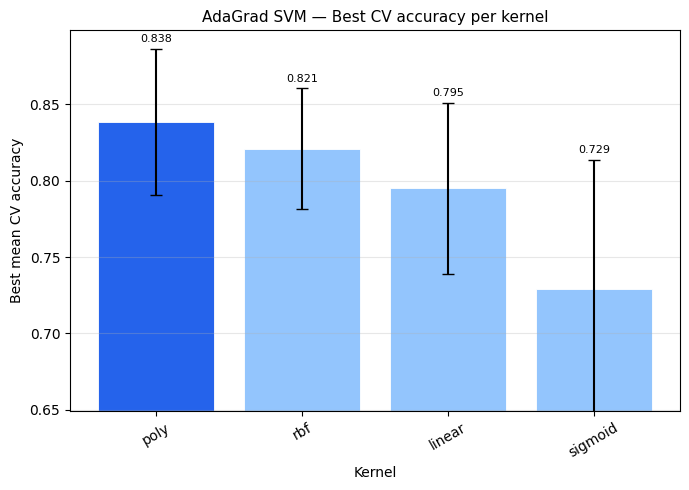

In [13]:
bpk = best_per_kernel(ada_out['search']['results_df'])

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(bpk))]
bars = ax.bar(bpk['kernel'], bpk['mean_cv'],
              yerr=bpk['std_cv'], capsize=4,
              color=colors, edgecolor='white', linewidth=0.6)
ax.set_title('AdaGrad SVM — Best CV accuracy per kernel', fontsize=11)
ax.set_xlabel('Kernel')
ax.set_ylabel('Best mean CV accuracy')
ax.set_ylim(max(0, bpk['mean_cv'].min() - 0.08), min(1, bpk['mean_cv'].max() + 0.06))
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar, val, std in zip(bars, bpk['mean_cv'], bpk['std_cv']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 2 Comparison: RM vs AdaGrad

In [14]:
comparison_df = pd.DataFrame([
    {
        "Algorithm": "RM baseline",
        "Kernel": best_rm_config["kernel"],
        "Best CV": round(best_rm_config["mean_cv"], 4),
        "Test Acc": round(final["test_acc_history"][-1], 4),
        "Notes": "Default hyperparameters",
    },
    {
        "Algorithm": "AdaGrad SVM",
        "Kernel": best_adagrad_config["kernel"],
        "Best CV": round(best_adagrad_config["mean_cv"], 4),
        "Test Acc": round(ada_out["test_acc"], 4),
        "Notes": "Joint kernel + AdaGrad tuning",
    },
])
comparison_df.index = comparison_df.index + 1
comparison_df.index.name = "#"
comparison_df.style.set_caption("Table — RM vs AdaGrad")

,Algorithm,Kernel,Best CV,Test Acc,Notes
#,,,,,
1,RM baseline,poly,0.835100,0.869600,Default hyperparameters
2,AdaGrad SVM,poly,0.838500,0.855100,Joint kernel + AdaGrad tuning


AdaGrad fits the same kernelized soft-margin SVM framework as the Robbins–Monro baseline, but uses adaptive coordinate-wise learning rates instead of a single decaying global step size.

In our experiments, AdaGrad achieved competitive performance under the same kernelized setup and therefore serves as a natural optimizer comparison within the assignment framework.

---
# Adam SVM — Optimization

Soft-margin SVM using **Adaptive Moment Estimation (Adam)** in the dual/representer form with kernels.

Adam extends AdaGrad by maintaining exponentially decaying averages of both the gradient (first moment $m_t$) and the squared gradient (second moment $v_t$), with bias-correction to account for their zero-initialisation:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)\, g_t, \qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2
$$
$$
\hat m_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat v_t = \frac{v_t}{1-\beta_2^t}
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat v_t}+\varepsilon}\,\hat m_t
$$

The same kernelized SVM objective is minimised as for RM and AdaGrad.

## 1 Joint Kernel + Adam Search

In [15]:
adam_out = run_svm_experiments(
    adam_svm, ADAM_PARAM_GRID,
    filepath="../data/ridings.csv",
    n_epochs_override=150,
    verbose=True,
)

  linear    combos tested:   36  best_cv so far: 0.7950  [85s]
  rbf       combos tested:  216  best_cv so far: 0.8205  [520s]
  poly      combos tested: 1188  best_cv so far: 0.8348  [2886s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8348  [3671s]


In [16]:
adam_best = adam_out["search"]["best_result"]

adam_df = pd.DataFrame([{
    "Kernel":        adam_best["kernel"],
    "Kernel Params": str(adam_best["kernel_params"]),
    "lambda_reg":    adam_best["lambda_reg"],
    "lr":            adam_best["learning_rate"],
    "beta1":         adam_best["beta1"],
    "beta2":         adam_best["beta2"],
    "epsilon":       adam_best["epsilon"],
    "n_epochs":      adam_best["n_epochs"],
    "Mean CV":       round(adam_best["mean_cv"], 4),
    "Std CV":        round(adam_best["std_cv"], 4),
    "Test Acc":      round(adam_out["test_acc"], 4),
}])
adam_df.index = adam_df.index + 1
adam_df.index.name = "#"
adam_df.style.set_caption("Table — Adam SVM best setting")

,Kernel,Kernel Params,lambda_reg,lr,beta1,beta2,epsilon,n_epochs,Mean CV,Std CV,Test Acc
#,,,,,,,,,,,
1,poly,"{'degree': 2, 'gamma': 1.0, 'coef0': 1.0}",0.001000,0.000100,0.500000,0.999000,0.000000,100,0.834800,0.045200,0.869600


In [17]:
# ── Hardcoded best Adam config
best_adam_config = adam_out['search']['best_result'].copy()


# best_adam_config = {
#     "kernel": "poly",
#     "kernel_params": {"degree": ..., "gamma": ..., "coef0": ...},
#     "lambda_reg": ...,
#     "learning_rate": ...,
#     "beta1": ...,
#     "beta2": ...,
#     "epsilon": ...,
#     "n_epochs": ...,
#     "mean_cv": ...,
# }

print(f"kernel         : {best_adam_config['kernel']}")
print(f"kernel_params  : {best_adam_config['kernel_params']}")
print(f"lambda_reg     : {best_adam_config['lambda_reg']}")
print(f"learning_rate  : {best_adam_config['learning_rate']}")
print(f"beta1          : {best_adam_config['beta1']}")
print(f"beta2          : {best_adam_config['beta2']}")
print(f"epsilon        : {best_adam_config['epsilon']}")
print(f"n_epochs       : {best_adam_config['n_epochs']}")
print(f"mean_cv        : {best_adam_config['mean_cv']:.4f}")

kernel         : poly
kernel_params  : {'degree': 2, 'gamma': 1.0, 'coef0': 1.0}
lambda_reg     : 0.001
learning_rate  : 0.0001
beta1          : 0.5
beta2          : 0.999
epsilon        : 1e-08
n_epochs       : 100
mean_cv        : 0.8348


In [18]:
print_rm_eval_report(
    adam_out["data"]["y_test"],
    adam_out["y_pred"],
    model_name="Adam SVM",
)

=== Adam SVM ===
Test Accuracy : 0.8696

  Std    : 0.3368
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.94      0.88        35
           1       0.93      0.79      0.86        34

    accuracy                           0.87        69
   macro avg       0.88      0.87      0.87        69
weighted avg       0.88      0.87      0.87        69

--- Confusion Matrix ---
[[33  2]
 [ 7 27]]



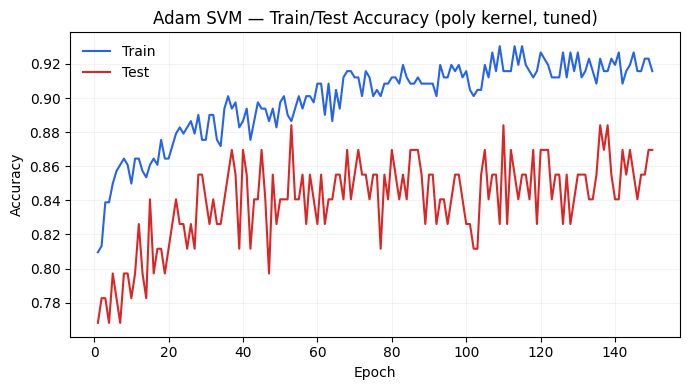

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
epochs = range(1, len(adam_out['fit']['train_acc_history']) + 1)
ax.plot(epochs, adam_out['fit']['train_acc_history'], label='Train', color='#2563eb', lw=1.5)
ax.plot(epochs, adam_out['fit']['test_acc_history'],  label='Test',  color='#dc2626', lw=1.5)
ax.set(xlabel='Epoch', ylabel='Accuracy',
       title=f"Adam SVM — Train/Test Accuracy ({best_adam_config['kernel']} kernel, tuned)")
ax.legend(frameon=False)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

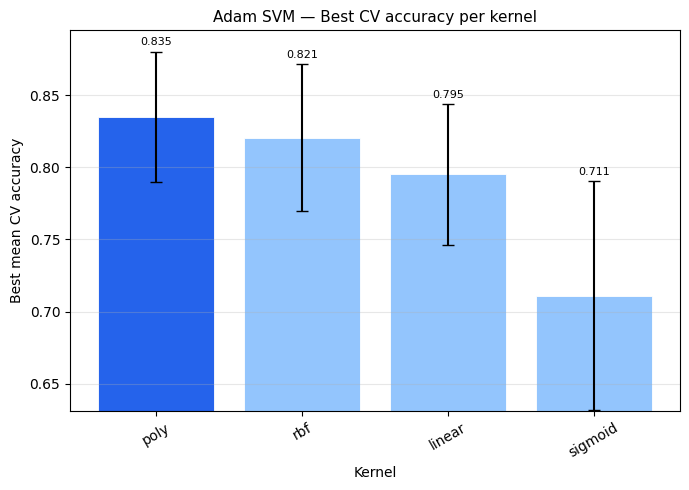

In [20]:
bpk = best_per_kernel(adam_out['search']['results_df'])

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(bpk))]
bars = ax.bar(bpk['kernel'], bpk['mean_cv'],
              yerr=bpk['std_cv'], capsize=4,
              color=colors, edgecolor='white', linewidth=0.6)
ax.set_title('Adam SVM — Best CV accuracy per kernel', fontsize=11)
ax.set_xlabel('Kernel')
ax.set_ylabel('Best mean CV accuracy')
ax.set_ylim(max(0, bpk['mean_cv'].min() - 0.08), min(1, bpk['mean_cv'].max() + 0.06))
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar, val, std in zip(bars, bpk['mean_cv'], bpk['std_cv']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 2 Three-Way Comparison: RM vs AdaGrad vs Adam

In [22]:
comparison_df = pd.DataFrame([
    {
        "Algorithm": "Robbins-Monro",
        "Kernel":    best_rm_config["kernel"],
        "Best CV":   round(best_rm_config["mean_cv"], 4),
        "Test Acc":  round(final["test_acc_history"][-1], 4),
    },
    {
        "Algorithm": "AdaGrad",
        "Kernel":    best_adagrad_config["kernel"],
        "Best CV":   round(best_adagrad_config["mean_cv"], 4),
        "Test Acc":  round(ada_out["test_acc"], 4),
    },
    {
        "Algorithm": "Adam",
        "Kernel":    best_adam_config["kernel"],
        "Best CV":   round(best_adam_config["mean_cv"], 4),
        "Test Acc":  round(adam_out["test_acc"], 4),
    },
])
comparison_df.index = comparison_df.index + 1
comparison_df.index.name = "#"
comparison_df.style.set_caption("Table — RM vs AdaGrad vs Adam (joint-tuned)")

,Algorithm,Kernel,Best CV,Test Acc
#,,,,
1,Robbins-Monro,poly,0.835100,0.869600
2,AdaGrad,poly,0.838500,0.855100
3,Adam,poly,0.834800,0.869600


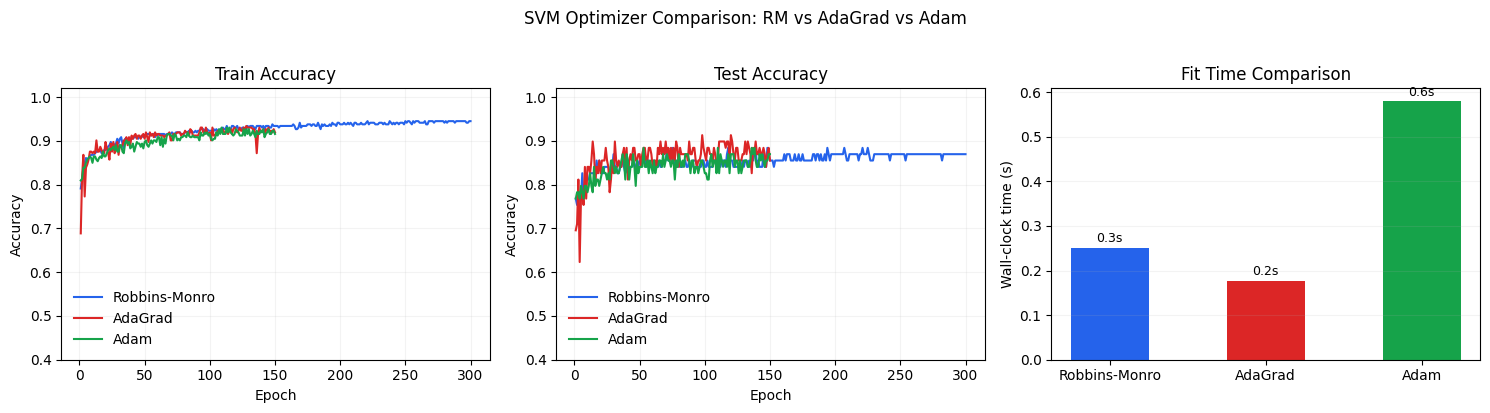

In [23]:
fits   = [final,          ada_out["fit"],  adam_out["fit"]]
colors = ["#2563eb",      "#dc2626",        "#16a34a"]
names  = ["Robbins-Monro", "AdaGrad",       "Adam"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train accuracy
ax = axes[0]
for fit, color, name in zip(fits, colors, names):
    ax.plot(range(1, len(fit["train_acc_history"]) + 1),
            fit["train_acc_history"], label=name, color=color, lw=1.5)
ax.set(xlabel="Epoch", ylabel="Accuracy", title="Train Accuracy")
ax.legend(frameon=False); ax.grid(True, alpha=0.15); ax.set_ylim(0.4, 1.02)

# Test accuracy
ax = axes[1]
for fit, color, name in zip(fits, colors, names):
    ax.plot(range(1, len(fit["test_acc_history"]) + 1),
            fit["test_acc_history"], label=name, color=color, lw=1.5)
ax.set(xlabel="Epoch", ylabel="Accuracy", title="Test Accuracy")
ax.legend(frameon=False); ax.grid(True, alpha=0.15); ax.set_ylim(0.4, 1.02)

# fit time
ax = axes[2]
times = [fit["fit_time_s"] for fit in fits]
bars  = ax.bar(names, times, color=colors, width=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(times) * 0.01,
            f"{t:.1f}s", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="Wall-clock time (s)", title="Fit Time Comparison")
ax.grid(True, alpha=0.15, axis="y")

fig.suptitle("SVM Optimizer Comparison: RM vs AdaGrad vs Adam", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Repeated Split Evaluation: RM & AdaGrad & Adam

Here we repeat the evaluation across 10 different stratified splits, keeping each optimizer's best hyperparameters fixed (from CV searches above)

In [24]:
experiments = [
    {
        "name":         "Robbins-Monro",
        "optimizer_fn": robbins_monro_svm,
        "best_result":  best_rm_config,
    },
    {
        "name":         "AdaGrad",
        "optimizer_fn": adagrad_svm,
        "best_result":  best_adagrad_config,
    },
    {
        "name":         "Adam",
        "optimizer_fn": adam_svm,
        "best_result":  best_adam_config,
    },
]

seeds = list(range(10))

summary_df, raw_df = repeated_eval_comparison(
    experiments,
    filepath="../data/ridings.csv",
    seeds=seeds,
)

print("=== Repeated Split Evaluation (10 seeds) ===\n")
display(summary_df)

=== Repeated Split Evaluation (10 seeds) ===



,Optimizer,Mean Accuracy,Std Accuracy,Min,Max
#,,,,,
1,AdaGrad,0.8232,±0.0280,0.7681,0.8551
2,Adam,0.8217,±0.0298,0.7826,0.8696
3,Robbins-Monro,0.8203,±0.0336,0.7536,0.8696


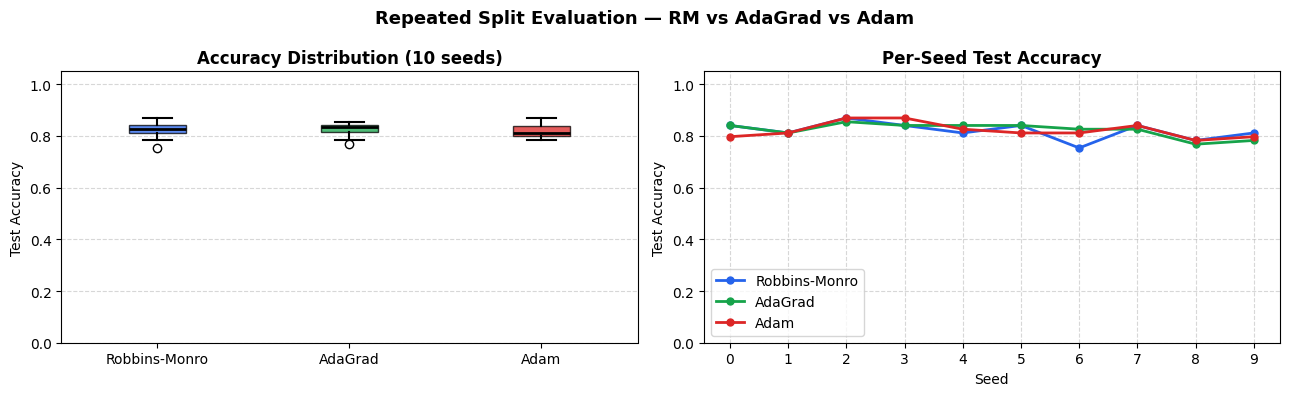

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

palette = {"Robbins-Monro": "#2563eb", "AdaGrad": "#16a34a", "Adam": "#dc2626"}
optimizers = ["Robbins-Monro", "AdaGrad", "Adam"]

# --- Box plot: accuracy distribution across 10 seeds ---
ax = axes[0]
data_to_plot = [raw_df[raw_df["Optimizer"] == opt]["Accuracy"].values for opt in optimizers]
bp = ax.boxplot(
    data_to_plot,
    labels=optimizers,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)
for patch, opt in zip(bp["boxes"], optimizers):
    patch.set_facecolor(palette[opt])
    patch.set_alpha(0.75)

ax.set_title("Accuracy Distribution (10 seeds)", fontweight="bold")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax = axes[1]
for opt in optimizers:
    sub = raw_df[raw_df["Optimizer"] == opt].sort_values("Seed")
    ax.plot(sub["Seed"], sub["Accuracy"], marker="o", label=opt,
            color=palette[opt], linewidth=2, markersize=5)

ax.set_title("Per-Seed Test Accuracy", fontweight="bold")
ax.set_xlabel("Seed")
ax.set_ylabel("Test Accuracy")
ax.set_xticks(seeds)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

plt.suptitle("Repeated Split Evaluation — RM vs AdaGrad vs Adam", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()